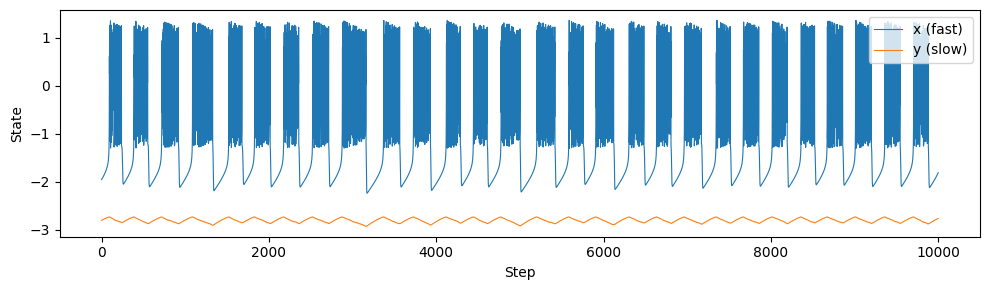

Multi-scale grid size : 1620
Single-scale grid size: 300

Running multi-scale grid search...
[multi   20/1620] elapsed=1.5s  best_closed_nrmse=1.158484
[multi   40/1620] elapsed=3.0s  best_closed_nrmse=1.158484
[multi   60/1620] elapsed=5.1s  best_closed_nrmse=1.158484
[multi   80/1620] elapsed=7.0s  best_closed_nrmse=1.158484
[multi  100/1620] elapsed=9.4s  best_closed_nrmse=1.158484
[multi  120/1620] elapsed=12.3s  best_closed_nrmse=1.158484
[multi  140/1620] elapsed=15.0s  best_closed_nrmse=1.158484
[multi  160/1620] elapsed=17.0s  best_closed_nrmse=1.158484
[multi  180/1620] elapsed=19.0s  best_closed_nrmse=1.158484
[multi  200/1620] elapsed=21.6s  best_closed_nrmse=1.158484
[multi  220/1620] elapsed=24.2s  best_closed_nrmse=1.158484
[multi  240/1620] elapsed=27.7s  best_closed_nrmse=1.158484
[multi  260/1620] elapsed=31.5s  best_closed_nrmse=1.158484
[multi  280/1620] elapsed=35.0s  best_closed_nrmse=1.158484
[multi  300/1620] elapsed=38.1s  best_closed_nrmse=1.158484
[multi  320/

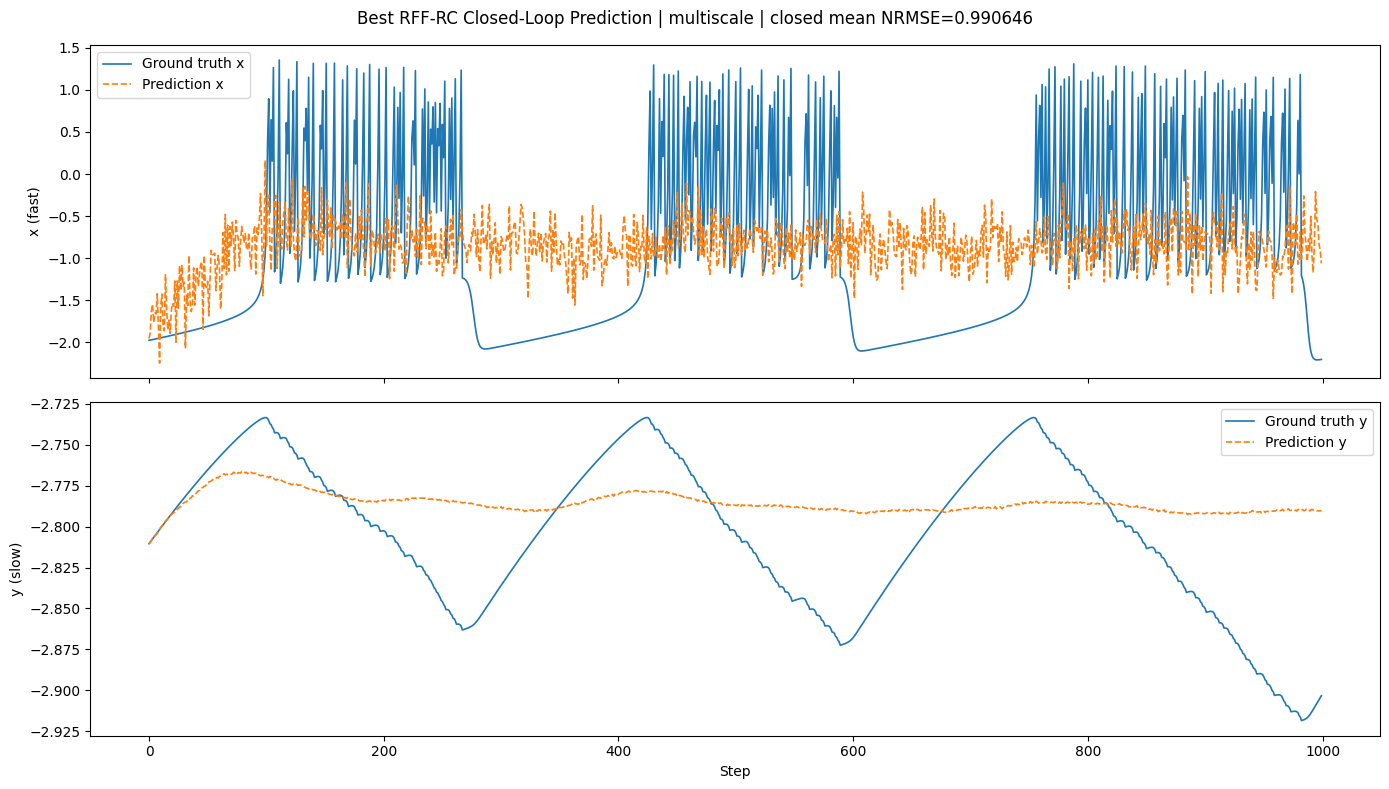

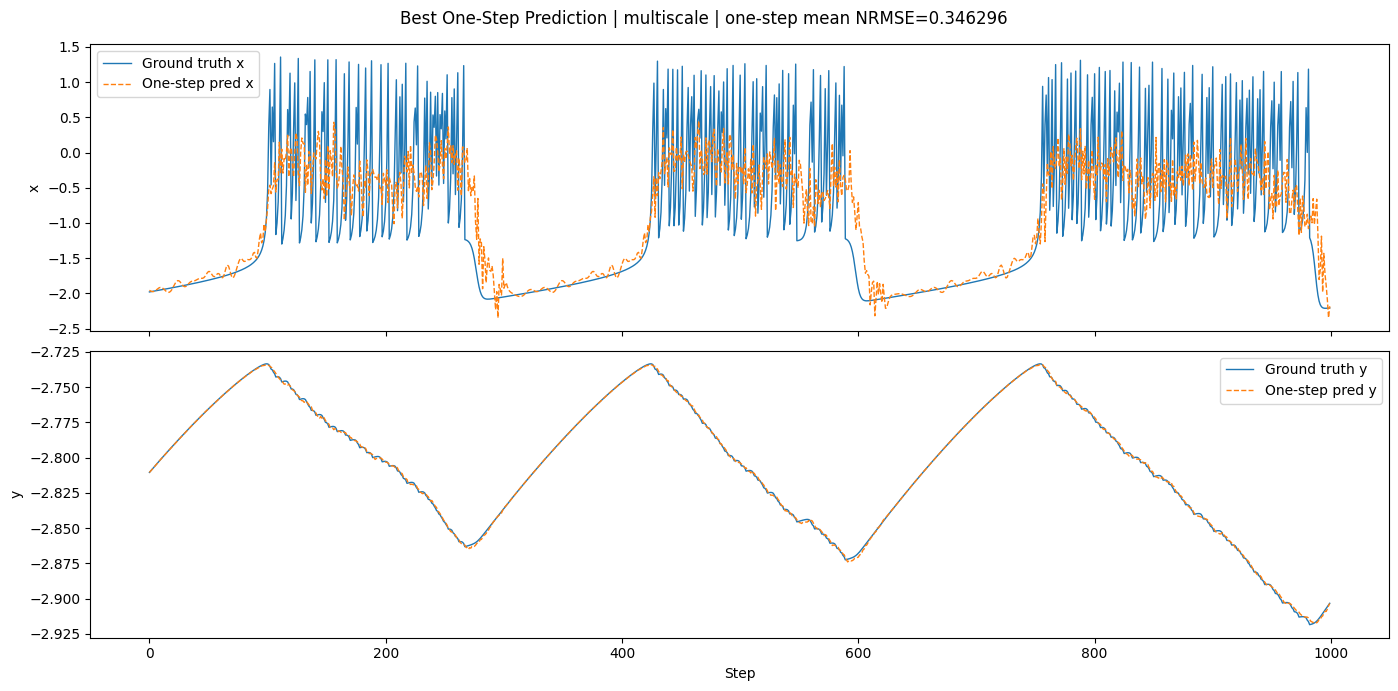

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
import time

from sklearn.linear_model import Ridge

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../..',)))
from lib.utils.reservoirpy import (
    fit_scaler, transform_array, inverse_transform_array
)

np.random.seed(42)


# ==========================================================
# LOAD DATA
# ==========================================================
# Expected:
#   - ideal/paper-faithful case: 2 columns [x, y]
#   - fallback: 1 column only
dataset = np.loadtxt('../../../data/chaotic_data/rulkov_map.csv', delimiter=',')

if dataset.ndim == 1:
    dataset = dataset.reshape(-1, 1)

# Keep first two columns if more exist
if dataset.shape[1] >= 2:
    dataset = dataset[:, :2]

fig, ax = plt.subplots(figsize=(10, 3))
if dataset.shape[1] == 1:
    ax.plot(dataset[:, 0], linewidth=0.8)
    ax.set_ylabel("Signal")
else:
    ax.plot(dataset[:, 0], linewidth=0.8, label='x (fast)')
    ax.plot(dataset[:, 1], linewidth=0.8, label='y (slow)')
    ax.legend()
    ax.set_ylabel("State")
ax.set_xlabel("Step")
plt.tight_layout()
plt.show()


# ==========================================================
# FIXED SETTINGS
# ==========================================================
train_len  = 4000
test_start = 4000
test_len   = 1000
seed       = 42
normalization = "minmax11"

# Use this to compare the paper's recommended multiscale formulation
# against a single-scale baseline.
COMPARE_SINGLE_SCALE = True


# ==========================================================
# DELAY EMBEDDING
# ==========================================================
def build_delay_embedding_multivar(data, lag):
    """
    data: (T, n_vars)

    returns:
      X: (T-lag, lag*n_vars)
      Y: (T-lag, n_vars)

    Layout:
      [x_t, x_{t-1}, ..., x_{t-lag+1},
       y_t, y_{t-1}, ..., y_{t-lag+1}, ...]
    """
    T, n_vars = data.shape
    X, Y = [], []

    for t in range(lag, T):
        row = []
        for j in range(n_vars):
            row.append(data[t-lag:t, j][::-1])
        X.append(np.concatenate(row))
        Y.append(data[t])

    return np.asarray(X), np.asarray(Y)


# ==========================================================
# RANDOM FOURIER FEATURES
# ==========================================================
def rff_map(X, W, b):
    """
    z(x) = sqrt(2/D) * cos(XW + b)
    X : (N, d)
    W : (d, D)
    b : (D,)
    """
    D = W.shape[1]
    return np.sqrt(2.0 / D) * np.cos(X @ W + b)


class MultiScaleRFFReservoir:
    """
    Variable-wise RFF blocks:
      one bandwidth per variable block
    """
    def __init__(self, lag, n_vars, D_per_var, alphas, rng_seed=42):
        self.lag = lag
        self.n_vars = n_vars
        self.D_per_var = D_per_var
        self.alphas = alphas
        self.rng = np.random.RandomState(rng_seed)

        self.W_blocks = []
        self.b_blocks = []

        for j in range(n_vars):
            D = int(D_per_var[j])
            alpha = float(alphas[j])

            # Gaussian-kernel RFF frequencies
            # sampled from Normal(0, 1/alpha^2)
            W = self.rng.normal(
                loc=0.0,
                scale=1.0 / alpha,
                size=(lag, D)
            )
            b = self.rng.uniform(0.0, 2.0 * np.pi, size=D)

            self.W_blocks.append(W)
            self.b_blocks.append(b)

    def transform(self, X_delay):
        feats = []
        for j in range(self.n_vars):
            start = j * self.lag
            end   = (j + 1) * self.lag
            Xj = X_delay[:, start:end]
            Zj = rff_map(Xj, self.W_blocks[j], self.b_blocks[j])
            feats.append(Zj)
        return np.hstack(feats)


class SingleScaleRFFReservoir:
    """
    Global RFF mapping on the full delay vector
    """
    def __init__(self, input_dim, D_total, alpha, rng_seed=42):
        self.rng = np.random.RandomState(rng_seed)
        self.W = self.rng.normal(
            loc=0.0,
            scale=1.0 / alpha,
            size=(input_dim, D_total)
        )
        self.b = self.rng.uniform(0.0, 2.0 * np.pi, size=D_total)

    def transform(self, X_delay):
        return rff_map(X_delay, self.W, self.b)


# ==========================================================
# METRICS / HELPERS
# ==========================================================
def nrmse_per_var(y_true, y_pred):
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))
    denom = np.std(y_true, axis=0)
    denom = np.where(denom == 0, 1.0, denom)
    return rmse / denom


def mean_nrmse(y_true, y_pred):
    return float(np.mean(nrmse_per_var(y_true, y_pred)))


def update_delay_vector(delay_vec, pred, n_vars, lag):
    """
    delay layout:
      [x_t, x_{t-1}, ..., x_{t-lag+1},
       y_t, y_{t-1}, ..., y_{t-lag+1}, ...]
    """
    out = delay_vec.copy()
    for j in range(n_vars):
        start = j * lag
        end   = (j + 1) * lag
        block = out[start:end]
        block[1:] = block[:-1]
        block[0]  = pred[j]
        out[start:end] = block
    return out


# ==========================================================
# EVALUATION FUNCTION
# ==========================================================
def evaluate_rff_rc(
    data,
    lag,
    mode,                    # "multiscale" or "singlescale"
    ridge_alpha,
    D_x=None,
    D_y=None,
    alpha_x=None,
    alpha_y=None,
    D_total=None,
    alpha_single=None,
    normalization="minmax11",
    train_len=4000,
    test_start=4000,
    test_len=1000,
    rng_seed=42,
):
    try:
        X_raw, Y_raw = build_delay_embedding_multivar(data, lag)

        # Split after embedding
        X_train_raw = X_raw[:train_len]
        Y_train_raw = Y_raw[:train_len]
        X_test_raw  = X_raw[test_start:test_start + test_len]
        Y_test_raw  = Y_raw[test_start:test_start + test_len]

        if len(X_test_raw) == 0 or len(X_train_raw) == 0:
            return None

        n_vars = Y_raw.shape[1]

        x_scaler = fit_scaler(X_train_raw, method=normalization)
        y_scaler = fit_scaler(Y_train_raw, method=normalization)

        X_train = transform_array(X_train_raw, x_scaler)
        Y_train = transform_array(Y_train_raw, y_scaler)
        X_test  = transform_array(X_test_raw,  x_scaler)
        Y_test  = transform_array(Y_test_raw,  y_scaler)

        # Build reservoir
        if mode == "multiscale":
            if n_vars == 1:
                # fallback if only one observable exists
                reservoir = SingleScaleRFFReservoir(
                    input_dim=lag,
                    D_total=int(D_x),
                    alpha=float(alpha_x),
                    rng_seed=rng_seed
                )
            else:
                reservoir = MultiScaleRFFReservoir(
                    lag=lag,
                    n_vars=n_vars,
                    D_per_var=[int(D_x), int(D_y)],
                    alphas=[float(alpha_x), float(alpha_y)],
                    rng_seed=rng_seed
                )

        elif mode == "singlescale":
            reservoir = SingleScaleRFFReservoir(
                input_dim=X_train.shape[1],
                D_total=int(D_total),
                alpha=float(alpha_single),
                rng_seed=rng_seed
            )
        else:
            raise ValueError(f"Unknown mode: {mode}")

        # Train readout
        F_train = reservoir.transform(X_train)
        readout = Ridge(alpha=ridge_alpha)
        readout.fit(F_train, Y_train)

        # One-step
        F_test = reservoir.transform(X_test)
        Y_pred_1_scaled = readout.predict(F_test)

        Y_pred_1 = inverse_transform_array(Y_pred_1_scaled, y_scaler)
        Y_true_1 = inverse_transform_array(Y_test, y_scaler)

        one_step_nrmse_vec = nrmse_per_var(Y_true_1, Y_pred_1)
        one_step_nrmse_mean = float(np.mean(one_step_nrmse_vec))

        # Closed-loop
        pred_len = len(X_test)
        current_delay = X_test[0].copy()
        Y_pred_cl_scaled = np.zeros((pred_len, n_vars))

        for k in range(pred_len):
            feat = reservoir.transform(current_delay.reshape(1, -1))
            pred = readout.predict(feat)[0]
            Y_pred_cl_scaled[k] = pred
            current_delay = update_delay_vector(current_delay, pred, n_vars, lag)

        Y_pred_cl = inverse_transform_array(Y_pred_cl_scaled, y_scaler)
        Y_true_cl = inverse_transform_array(Y_test[:pred_len], y_scaler)

        closed_nrmse_vec = nrmse_per_var(Y_true_cl, Y_pred_cl)
        closed_nrmse_mean = float(np.mean(closed_nrmse_vec))

        return {
            "mode": mode,
            "lag": lag,
            "ridge_alpha": ridge_alpha,
            "one_step_nrmse_mean": one_step_nrmse_mean,
            "closed_nrmse_mean": closed_nrmse_mean,
            "one_step_nrmse_vec": one_step_nrmse_vec,
            "closed_nrmse_vec": closed_nrmse_vec,
            "Y_true_cl": Y_true_cl,
            "Y_pred_cl": Y_pred_cl,
            "Y_true_1": Y_true_1,
            "Y_pred_1": Y_pred_1,
            "n_vars": n_vars,
            "x_scaler": x_scaler,
            "y_scaler": y_scaler,
            "readout": readout,
            "reservoir": reservoir,
        }

    except Exception as e:
        print(f"ERROR in evaluate_rff_rc: {e}")
        return None


# ==========================================================
# PARAMETER GRIDS
# ==========================================================
n_vars_data = dataset.shape[1]

# Paper-inspired default idea for Rulkov:
# fast x -> smaller bandwidth
# slow y -> larger bandwidth
# so the multi-scale grid should allow that pattern.
grid_multiscale = {
    "lag": [6, 10, 14, 20],
    "D_x": [200, 500, 1000],
    "D_y": [200, 500, 1000],
    "alpha_x": [0.03, 0.1, 0.3],
    "alpha_y": [3.0, 10.0, 30.0],
    "ridge_alpha": [1e-8, 1e-6, 1e-4, 1e-2, 1.0],
}

grid_singlescale = {
    "lag": [6, 10, 14, 20],
    "D_total": [400, 1000, 2000],
    "alpha_single": [0.03, 0.1, 0.3, 1.0, 3.0],
    "ridge_alpha": [1e-8, 1e-6, 1e-4, 1e-2, 1.0],
}


# ==========================================================
# BUILD COMBINATIONS
# ==========================================================
multi_keys = list(grid_multiscale.keys())
multi_combos = list(itertools.product(*[grid_multiscale[k] for k in multi_keys]))

single_keys = list(grid_singlescale.keys())
single_combos = list(itertools.product(*[grid_singlescale[k] for k in single_keys]))

print(f"Multi-scale grid size : {len(multi_combos)}")
if COMPARE_SINGLE_SCALE:
    print(f"Single-scale grid size: {len(single_combos)}")


# ==========================================================
# RUN GRID SEARCH
# ==========================================================
results = []
best_result = None
best_score = np.inf

t0 = time.time()

# ---- Multi-scale search ----
print("\nRunning multi-scale grid search...")
for idx, combo in enumerate(multi_combos, 1):
    params = dict(zip(multi_keys, combo))

    result = evaluate_rff_rc(
        data=dataset,
        lag=params["lag"],
        mode="multiscale",
        ridge_alpha=params["ridge_alpha"],
        D_x=params["D_x"],
        D_y=params["D_y"],
        alpha_x=params["alpha_x"],
        alpha_y=params["alpha_y"],
        normalization=normalization,
        train_len=train_len,
        test_start=test_start,
        test_len=test_len,
        rng_seed=seed,
    )

    if result is None:
        continue

    row = {
        "mode": "multiscale",
        "lag": params["lag"],
        "D_x": params["D_x"],
        "D_y": params["D_y"],
        "alpha_x": params["alpha_x"],
        "alpha_y": params["alpha_y"],
        "ridge_alpha": params["ridge_alpha"],
        "one_step_nrmse_mean": result["one_step_nrmse_mean"],
        "closed_nrmse_mean": result["closed_nrmse_mean"],
        "one_step_nrmse_vec": result["one_step_nrmse_vec"],
        "closed_nrmse_vec": result["closed_nrmse_vec"],
        "result_obj": result,
    }
    results.append(row)

    score = result["closed_nrmse_mean"]
    if score < best_score:
        best_score = score
        best_result = row

    if idx % 20 == 0 or idx == len(multi_combos):
        elapsed = time.time() - t0
        print(
            f"[multi {idx:4d}/{len(multi_combos)}] "
            f"elapsed={elapsed:.1f}s  "
            f"best_closed_nrmse={best_score:.6f}"
        )


# ---- Single-scale search ----
if COMPARE_SINGLE_SCALE:
    print("\nRunning single-scale grid search...")
    for idx, combo in enumerate(single_combos, 1):
        params = dict(zip(single_keys, combo))

        result = evaluate_rff_rc(
            data=dataset,
            lag=params["lag"],
            mode="singlescale",
            ridge_alpha=params["ridge_alpha"],
            D_total=params["D_total"],
            alpha_single=params["alpha_single"],
            normalization=normalization,
            train_len=train_len,
            test_start=test_start,
            test_len=test_len,
            rng_seed=seed,
        )

        if result is None:
            continue

        row = {
            "mode": "singlescale",
            "lag": params["lag"],
            "D_total": params["D_total"],
            "alpha_single": params["alpha_single"],
            "ridge_alpha": params["ridge_alpha"],
            "one_step_nrmse_mean": result["one_step_nrmse_mean"],
            "closed_nrmse_mean": result["closed_nrmse_mean"],
            "one_step_nrmse_vec": result["one_step_nrmse_vec"],
            "closed_nrmse_vec": result["closed_nrmse_vec"],
            "result_obj": result,
        }
        results.append(row)

        score = result["closed_nrmse_mean"]
        if score < best_score:
            best_score = score
            best_result = row

        if idx % 20 == 0 or idx == len(single_combos):
            elapsed = time.time() - t0
            print(
                f"[single {idx:4d}/{len(single_combos)}] "
                f"elapsed={elapsed:.1f}s  "
                f"best_closed_nrmse={best_score:.6f}"
            )


total_time = time.time() - t0


# ==========================================================
# SORT / PRINT RESULTS
# ==========================================================
results_sorted = sorted(results, key=lambda r: r["closed_nrmse_mean"])

print("\n" + "=" * 90)
print("GRID SEARCH COMPLETE")
print(f"Total runtime: {total_time:.2f} s")
print(f"Total evaluated configs: {len(results_sorted)}")
print(f"Best closed-loop mean NRMSE: {results_sorted[0]['closed_nrmse_mean']:.10f}")
print("=" * 90)

print("\nTop 15 configurations by CLOSED-LOOP mean NRMSE:\n")

for rank, r in enumerate(results_sorted[:15], 1):
    if r["mode"] == "multiscale":
        print(
            f"{rank:2d}. mode={r['mode']:11s} | "
            f"lag={r['lag']:2d} | "
            f"D_x={r['D_x']:4d} | D_y={r['D_y']:4d} | "
            f"alpha_x={r['alpha_x']:6.3f} | alpha_y={r['alpha_y']:6.3f} | "
            f"ridge={r['ridge_alpha']:.1e} | "
            f"one_step={r['one_step_nrmse_mean']:.8f} | "
            f"closed={r['closed_nrmse_mean']:.8f}"
        )
    else:
        print(
            f"{rank:2d}. mode={r['mode']:11s} | "
            f"lag={r['lag']:2d} | "
            f"D_total={r['D_total']:4d} | "
            f"alpha={r['alpha_single']:6.3f} | "
            f"ridge={r['ridge_alpha']:.1e} | "
            f"one_step={r['one_step_nrmse_mean']:.8f} | "
            f"closed={r['closed_nrmse_mean']:.8f}"
        )


# ==========================================================
# BEST MODEL SUMMARY
# ==========================================================
print("\n" + "=" * 90)
print("BEST CONFIGURATION")
print("=" * 90)

if best_result["mode"] == "multiscale":
    print(f"mode         : {best_result['mode']}")
    print(f"lag          : {best_result['lag']}")
    print(f"D_x          : {best_result['D_x']}")
    print(f"D_y          : {best_result['D_y']}")
    print(f"alpha_x      : {best_result['alpha_x']}")
    print(f"alpha_y      : {best_result['alpha_y']}")
    print(f"ridge_alpha  : {best_result['ridge_alpha']}")
else:
    print(f"mode         : {best_result['mode']}")
    print(f"lag          : {best_result['lag']}")
    print(f"D_total      : {best_result['D_total']}")
    print(f"alpha_single : {best_result['alpha_single']}")
    print(f"ridge_alpha  : {best_result['ridge_alpha']}")

print(f"one-step mean NRMSE    : {best_result['one_step_nrmse_mean']:.10f}")
print(f"closed-loop mean NRMSE : {best_result['closed_nrmse_mean']:.10f}")

br = best_result["result_obj"]
print(f"one-step per variable  : {br['one_step_nrmse_vec']}")
print(f"closed-loop per var    : {br['closed_nrmse_vec']}")


# ==========================================================
# PLOT BEST CLOSED-LOOP
# ==========================================================
Y_true_cl = br["Y_true_cl"]
Y_pred_cl = br["Y_pred_cl"]
n_vars = br["n_vars"]

if n_vars == 1:
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(Y_true_cl[:, 0], label="Ground truth", linewidth=1.2)
    ax.plot(Y_pred_cl[:, 0], '--', label="Prediction", linewidth=1.2)
    ax.set_xlabel("Step")
    ax.set_ylabel("Signal")
    ax.set_title(
        f"Best RFF-RC Closed-Loop Prediction | "
        f"{best_result['mode']} | "
        f"closed NRMSE={best_result['closed_nrmse_mean']:.6f}"
    )
    ax.legend()
    plt.tight_layout()
    plt.show()

else:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    axes[0].plot(Y_true_cl[:, 0], label="Ground truth x", linewidth=1.2)
    axes[0].plot(Y_pred_cl[:, 0], '--', label="Prediction x", linewidth=1.2)
    axes[0].set_ylabel("x (fast)")
    axes[0].legend()

    axes[1].plot(Y_true_cl[:, 1], label="Ground truth y", linewidth=1.2)
    axes[1].plot(Y_pred_cl[:, 1], '--', label="Prediction y", linewidth=1.2)
    axes[1].set_ylabel("y (slow)")
    axes[1].set_xlabel("Step")
    axes[1].legend()

    fig.suptitle(
        f"Best RFF-RC Closed-Loop Prediction | {best_result['mode']} | "
        f"closed mean NRMSE={best_result['closed_nrmse_mean']:.6f}"
    )
    plt.tight_layout()
    plt.show()


# ==========================================================
# OPTIONAL: PLOT BEST ONE-STEP
# ==========================================================
Y_true_1 = br["Y_true_1"]
Y_pred_1 = br["Y_pred_1"]

if n_vars == 1:
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(Y_true_1[:, 0], label="Ground truth", linewidth=1.0)
    ax.plot(Y_pred_1[:, 0], '--', label="One-step prediction", linewidth=1.0)
    ax.set_title(
        f"Best One-Step Prediction | {best_result['mode']} | "
        f"one-step NRMSE={best_result['one_step_nrmse_mean']:.6f}"
    )
    ax.legend()
    plt.tight_layout()
    plt.show()

else:
    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    axes[0].plot(Y_true_1[:, 0], label="Ground truth x", linewidth=1.0)
    axes[0].plot(Y_pred_1[:, 0], '--', label="One-step pred x", linewidth=1.0)
    axes[0].legend()
    axes[0].set_ylabel("x")

    axes[1].plot(Y_true_1[:, 1], label="Ground truth y", linewidth=1.0)
    axes[1].plot(Y_pred_1[:, 1], '--', label="One-step pred y", linewidth=1.0)
    axes[1].legend()
    axes[1].set_ylabel("y")
    axes[1].set_xlabel("Step")

    fig.suptitle(
        f"Best One-Step Prediction | {best_result['mode']} | "
        f"one-step mean NRMSE={best_result['one_step_nrmse_mean']:.6f}"
    )
    plt.tight_layout()
    plt.show()